In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")

models = ['Gaussian', 'Adaptive', 'MOG', 'MOG2', 'LSBP', 'LOBSTER', 'SUBSENSE', 'ZBS']
map_scores = [x / 100 for x in [51.24 , 64.78, 59.29, 62.57, 55.14, 57.83, 60.24, 56.08]]
# Define categories: 'sota' or 'own'
categories = [ 'own', 'own', 'sota', 'sota', 'sota', 'sota', 'sota', 'sota'] # Update this list to mark your own method

times = [172.5, 232.55, 375.75, 198.18, 434.26, 1793.22, 3066.49, 594.72]

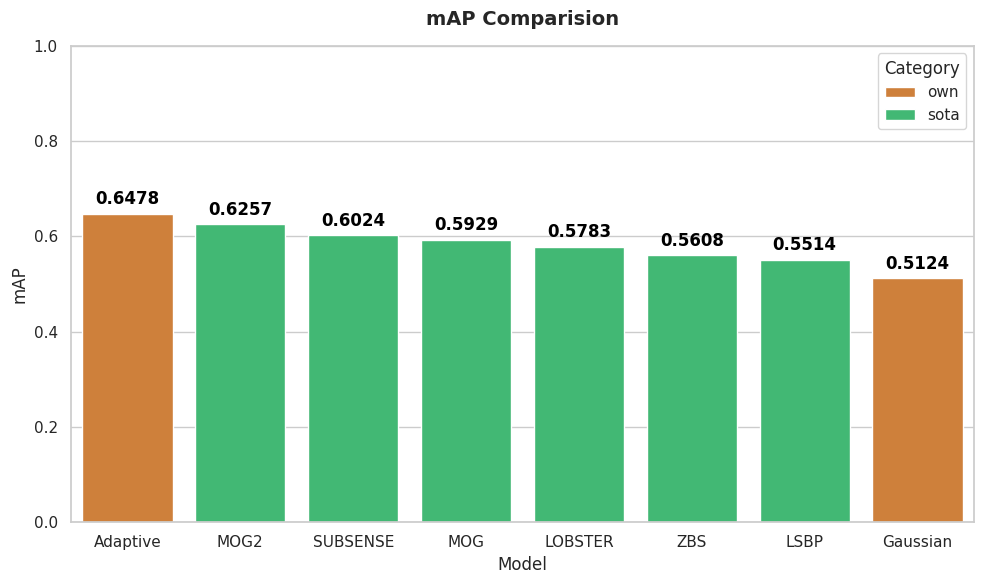

In [2]:
plt.figure(figsize=(10, 6))

# Create a DataFrame for easier handling
df = pd.DataFrame({'Model': models, 'mAP': map_scores, 'Category': categories})
df = df.sort_values('mAP', ascending=False)

# Define specific colors for categories
palette = {"sota": "#2ecc71", "own": "#e67e22"} # Green and Orange

ax = sns.barplot(data=df, x='Model', y='mAP', hue='Category', palette=palette, dodge=False)

for i, v in enumerate(df['mAP']):
    ax.text(i, v + 0.02, f"{v:.4f}", color='black', ha='center', fontweight='bold')

plt.title('mAP Comparision', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Model', fontsize=12)
plt.ylabel('mAP', fontsize=12)
plt.ylim(0, 1) 
plt.legend(title='Category')

plt.tight_layout()
plt.show()

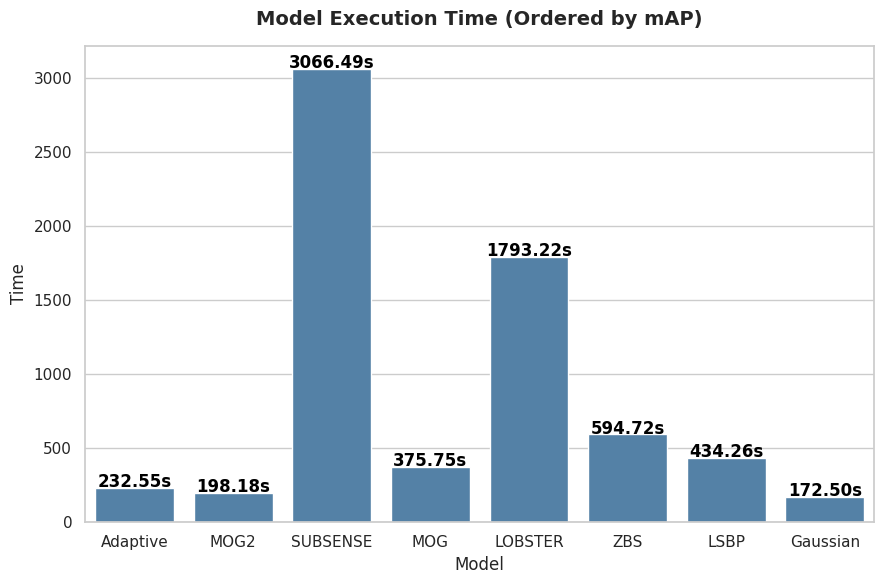

In [3]:
# Filter models with valid times and associate them with their mAP scores for sorting
data_with_times = [(m, t, s) for m, t, s in zip(models, times, map_scores) if t is not None]

# Sort by mAP (index 2) in descending order to match the mAP plot
data_with_times.sort(key=lambda x: x[2], reverse=True)

sorted_models_time = [x[0] for x in data_with_times]
sorted_times = [x[1] for x in data_with_times]

plt.figure(figsize=(9, 6))

ax = sns.barplot(x=sorted_models_time, y=sorted_times, color="steelblue")

for i, v in enumerate(sorted_times):
    ax.text(i, v + 5, f"{v:.2f}s", color='black', ha='center', fontweight='bold')

plt.title('Model Execution Time (Ordered by mAP)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Time', fontsize=12)

plt.tight_layout()
plt.show()